In [1]:
from sentence_transformers import SentenceTransformer
from umap import UMAP
import hdbscan
from sklearn.feature_extraction.text import CountVectorizer
from bertopic import BERTopic
from bertopic.vectorizers import ClassTfidfTransformer
import pandas as pd
import numpy as np

# item prefix
prefix = ''

# item texts
sentences = [
'I found myself getting upset by quite trivial things.',
'I was aware of dryness of my mouth.',
"I couldn't seem to experience any positive feeling at all.",
'I experienced breathing difficulty (eg, excessively rapid breathing, breathlessness in the absence of physical exertion).',
"I just couldn't seem to get going.",
'I tended to over-react to situations.',
'I had a feeling of shakiness (eg, legs going to give way).',
'I found it difficult to relax.',
'I found myself in situations that made me so anxious I was most relieved when they ended.',
'I felt that I had nothing to look forward to.',
'I found myself getting upset rather easily.',
'I felt that I was using a lot of nervous energy.',
'I felt sad and depressed.',
'I found myself getting impatient when I was delayed in any way (eg, elevators, traffic lights, being kept waiting).',
'I had a feeling of faintness.',
'I felt that I had lost interest in just about everything.',
"I felt I wasn't worth much as a person.",
'I felt that I was rather touchy.',
'I perspired noticeably (eg, hands sweaty) in the absence of high temperatures or physical exertion.',
'I felt scared without any good reason.',
"I felt that life wasn't worthwhile.",
'I found it hard to wind down.',
'I had difficulty in swallowing.',
"I couldn't seem to get any enjoyment out of the things I did.",
'I was aware of the action of my heart in the absence of physical exertion (eg, sense of heart rate increase, heart missing a beat).',
'I felt down-hearted and blue.',
'I found that I was very irritable.',
'I felt I was close to panic.',
'I found it hard to calm down after something upset me.',
'I feared that I would be "thrown" by some trivial but unfamiliar task.',
'I was unable to become enthusiastic about anything.',
'I found it difficult to tolerate interruptions to what I was doing.',
'I was in a state of nervous tension.',
'I felt I was pretty worthless.',
'I was intolerant of anything that kept me from getting on with what I was doing.',
'I felt terrified.',
'I could see nothing in the future to be hopeful about.',
'I felt that life was meaningless.',
'I found myself getting agitated.',
'I was worried about situations in which I might panic and make a fool of myself.',
'I experienced trembling (eg, in the hands).',
'I found it difficult to work up the initiative to do things.'
]

sentences = np.array(sentences)
sentences = prefix + sentences

print("Preprocessed sentences:")
print(sentences)

/opt/anaconda3/envs/survey-simp-mac/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Preprocessed sentences:
['I found myself getting upset by quite trivial things.'
 'I was aware of dryness of my mouth.'
 "I couldn't seem to experience any positive feeling at all."
 'I experienced breathing difficulty (eg, excessively rapid breathing, breathlessness in the absence of physical exertion).'
 "I just couldn't seem to get going."
 'I tended to over-react to situations.'
 'I had a feeling of shakiness (eg, legs going to give way).'
 'I found it difficult to relax.'
 'I found myself in situations that made me so anxious I was most relieved when they ended.'
 'I felt that I had nothing to look forward to.'
 'I found myself getting upset rather easily.'
 'I felt that I was using a lot of nervous energy.'
 'I felt sad and depressed.'
 'I found myself getting impatient when I was delayed in any way (eg, elevators, traffic lights, being kept waiting).'
 'I had a feeling of faintness.'
 'I felt that I had lost interest in just about everything.'
 "I felt I wasn't worth much as a p

In [2]:
# Step 1-1: Embed item texts into embeddings
embedding_model = SentenceTransformer("Qwen/Qwen3-Embedding-4B")
embedding_model.eval()
embeddings = embedding_model.encode(sentences, prompt='Instruct: The following query comes from a psychological scale\nQuery:')

# Step 1-2: UMAP dimension reduction
umap_model = UMAP(n_neighbors=3, n_components=5, min_dist=0.0, metric='cosine', random_state=42)

# Step 2: HDBSCAN clustering preparation
hdbscan_model = hdbscan.HDBSCAN(min_cluster_size=2, min_samples=1, metric='euclidean', prediction_data=True)

# Step 3: Vectorizer, Keyword model (ctfidf) initialization
vectorizer_model = CountVectorizer(stop_words="english")
ctfidf_model = ClassTfidfTransformer()
print("Steps 1,2,3 complete.")

Loading checkpoint shards: 100%|██████████| 2/2 [00:01<00:00,  1.35it/s]


Steps 1,2,3 complete.


In [3]:
# Step 4: Topic modeling
# Build Topic modeling framework and set the parameters
topic_model = BERTopic(
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_model,
    ctfidf_model=ctfidf_model,
    embedding_model=embedding_model,
    nr_topics=4,
    top_n_words=5
)

# Semantic clustering and topic modeling
topics, probs = topic_model.fit_transform(sentences, embeddings)
print("Step 4: Topic modeling complete.")

Step 4: Topic modeling complete.


In [4]:
# Step 5: Representative-item selection
# Obtain the topic information
topic_info = topic_model.get_topic_info()

Qid = [f"Q{i+1}" for i in range(len(sentences))]
df = pd.DataFrame({
    "Qid": Qid,
    "Question": sentences,
    "Topic": topics,
    "Probability": probs
})

# Obtain the most representative items and build results
representatives = df[df["Topic"] != -1].sort_values("Probability", ascending=False).groupby("Topic").first().reset_index()
representatives = representatives.rename(columns={"Question": "Representative Question", "Probability": "Confidence"})

# Aggregate the keywords
topic_rows = []
for topic_id in representatives["Topic"]:
    words = topic_model.get_topic(topic_id)  # [(word, score), ...]
    row = {
        "Topic ID": topic_id,
        "Top Keywords": ", ".join([f"{w} ({s:.3f})" for w, s in words]),
        "Representative Question": representatives.loc[representatives["Topic"] == topic_id, "Representative Question"].values[0],
        "Confidence": representatives.loc[representatives["Topic"] == topic_id, "Confidence"].values[0]
    }
    topic_rows.append(row)

final_df = pd.DataFrame(topic_rows)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
print("Result aggregation complete.")

Result aggregation complete.


In [5]:
# Result
# df: the basic overall result
print("Overall analysis result:")
print(df)

Overall analysis result:
    Qid                                           Question  Topic  Probability
0    Q1  I found myself getting upset by quite trivial ...      2     1.000000
1    Q2                I was aware of dryness of my mouth.      3     1.000000
2    Q3  I couldn't seem to experience any positive fee...      1     1.000000
3    Q4  I experienced breathing difficulty (eg, excess...      0     1.000000
4    Q5                 I just couldn't seem to get going.      1     1.000000
5    Q6              I tended to over-react to situations.      2     1.000000
6    Q7  I had a feeling of shakiness (eg, legs going t...      0     1.000000
7    Q8                     I found it difficult to relax.      2     1.000000
8    Q9  I found myself in situations that made me so a...      0     0.707320
9   Q10      I felt that I had nothing to look forward to.      1     1.000000
10  Q11        I found myself getting upset rather easily.      2     1.000000
11  Q12   I felt that I was

In [6]:
# final_df: the keywords and representative items in each topic
print("Keywords and representative questions information:")
print(final_df)

Keywords and representative questions information:
   Topic ID                                       Top Keywords  \
0         0  absence (0.107), physical (0.107), heart (0.10...   
1         1  felt (0.250), couldn (0.178), just (0.135), wa...   
2         2  getting (0.231), upset (0.210), kept (0.160), ...   
3         3  mouth (0.743), dryness (0.743), swallowing (0....   

                             Representative Question  Confidence  
0  I was aware of the action of my heart in the a...         1.0  
1  I couldn't seem to get any enjoyment out of th...         1.0  
2  I found myself getting upset by quite trivial ...         1.0  
3                    I had difficulty in swallowing.         1.0  


In [7]:
# Save result
df.to_csv('dass-42-result-reuslt-overall.csv', index=True)
final_df.to_csv('dass-42-result-keyword-representative.csv', index=True)

In [8]:
# Visualization
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from scipy.spatial import ConvexHull
from matplotlib.patches import Ellipse

# 1. Extend dataframes (add ground truth factor label) for visualization
real_factor = ['S', 'A', 'D', 'A', 'D', 'S', 'A', 'S', 'A', 'D', 'S', 'S', 'D', 'S', 'A', 'D', 'D', 'S', 'A', 'A', 'D', 'S', 'A', 'D', 'A', 'D', 'S', 'A', 'S', 'A', 'D', 'S', 'S', 'D', 'S', 'A', 'D', 'D', 'S', 'A', 'A', 'D']

df['Factor'] = real_factor
print(df)

    Qid                                           Question  Topic  \
0    Q1  I found myself getting upset by quite trivial ...      2   
1    Q2                I was aware of dryness of my mouth.      3   
2    Q3  I couldn't seem to experience any positive fee...      1   
3    Q4  I experienced breathing difficulty (eg, excess...      0   
4    Q5                 I just couldn't seem to get going.      1   
5    Q6              I tended to over-react to situations.      2   
6    Q7  I had a feeling of shakiness (eg, legs going t...      0   
7    Q8                     I found it difficult to relax.      2   
8    Q9  I found myself in situations that made me so a...      0   
9   Q10      I felt that I had nothing to look forward to.      1   
10  Q11        I found myself getting upset rather easily.      2   
11  Q12   I felt that I was using a lot of nervous energy.      0   
12  Q13                          I felt sad and depressed.      1   
13  Q14  I found myself getting im

In [9]:
# 2. Prepare embeddings
embeddings = np.array(embeddings)

# 3. Run t-SNE
n = embeddings.shape[0]
perplexity = min(30, max(5, (n - 1) // 3))

tsne_2d = TSNE(
    n_components=2,
    perplexity=perplexity,
    init="pca",
    learning_rate="auto",
    metric="cosine",
    random_state=42
)
xy_tsne = tsne_2d.fit_transform(embeddings)
print("Embedding processing complete.")

/opt/anaconda3/envs/survey-simp-mac/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/survey-simp-mac/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/survey-simp-mac/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/survey-simp-mac/lib/python3.13/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A @ Q)
/opt/anaconda3/envs/survey-simp-mac/lib/python3.13/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A @ Q)
/opt/anaconda3/envs/survey-simp-mac/lib/python3.13/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning: invalid value encountered in matmul
  Q, _ = normalizer(A @ Q)
/op

Embedding processing complete.


In [10]:
# 4. Visualization color setting
BRIGHT10 = [
    "#1f77b4",  # blue
    "#ff7f0e",  # orange
    "#2ca02c",  # green
    "#d62728",  # red
    "#9467bd",  # purple
    "#8c564b",  # brown
    "#e377c2",  # pink
    "#7f7f7f",  # gray
    "#bcbd22",  # olive
    "#17becf",  # cyan
]

def ordered_factors(factor_list):
    canon = ["Depression", "Anxiety", "Stress", "D", "A", "S"]
    fset = set(factor_list)
    ordered = [f for f in canon if f in fset]
    rest = [f for f in factor_list if f not in ordered]
    return ordered + sorted(rest)

factors = ordered_factors(sorted(df["Factor"].astype(str).unique().tolist()))
topics = sorted(df["Topic"].astype(str).unique().tolist())

factor2color = {}
for i, fac in enumerate(factors):
    factor2color[fac] = BRIGHT10[i % len(BRIGHT10)]

# 5. Helper functions
def majority_factor(sub_df: pd.DataFrame) -> str:
    return sub_df["Factor"].value_counts().idxmax()

def draw_topic_boundary(ax, pts, color, draw_hull=True, draw_ellipse=True, ellipse_n_std=1.3):
    k = pts.shape[0]

    # Convex hull
    if draw_hull and k >= 2:
        if k >= 3:
            hull = ConvexHull(pts)
            poly = pts[hull.vertices]
            poly = np.vstack([poly, poly[0]])
            ax.plot(poly[:, 0], poly[:, 1], color=color, linewidth=1.6, alpha=0.95)
            ax.fill(poly[:, 0], poly[:, 1], color=color, alpha=0.06)
        else:
            ax.plot(pts[:, 0], pts[:, 1], color=color, linewidth=1.6, alpha=0.95)

    # Covariance ellipse
    if draw_ellipse and k >= 3:
        cov = np.cov(pts.T)
        if np.linalg.matrix_rank(cov) == 2:
            mean = pts.mean(axis=0)
            vals, vecs = np.linalg.eigh(cov)
            order = vals.argsort()[::-1]
            vals, vecs = vals[order], vecs[:, order]
            theta = np.degrees(np.arctan2(vecs[1, 0], vecs[0, 0]))
            width, height = 2 * ellipse_n_std * np.sqrt(vals)

            ell_fill = Ellipse(
                xy=mean,
                width=width,
                height=height,
                angle=theta,
                facecolor=color,
                edgecolor="none",
                alpha=0.05
            )
            ax.add_patch(ell_fill)

            ell_edge = Ellipse(
                xy=mean,
                width=width,
                height=height,
                angle=theta,
                fill=False,
                edgecolor=color,
                linewidth=1.4,
                alpha=0.95
            )
            ax.add_patch(ell_edge)

print("Visualization preparation...")

Visualization preparation...


Two-Dimensional Visualization of the Semantic Representation Space: 


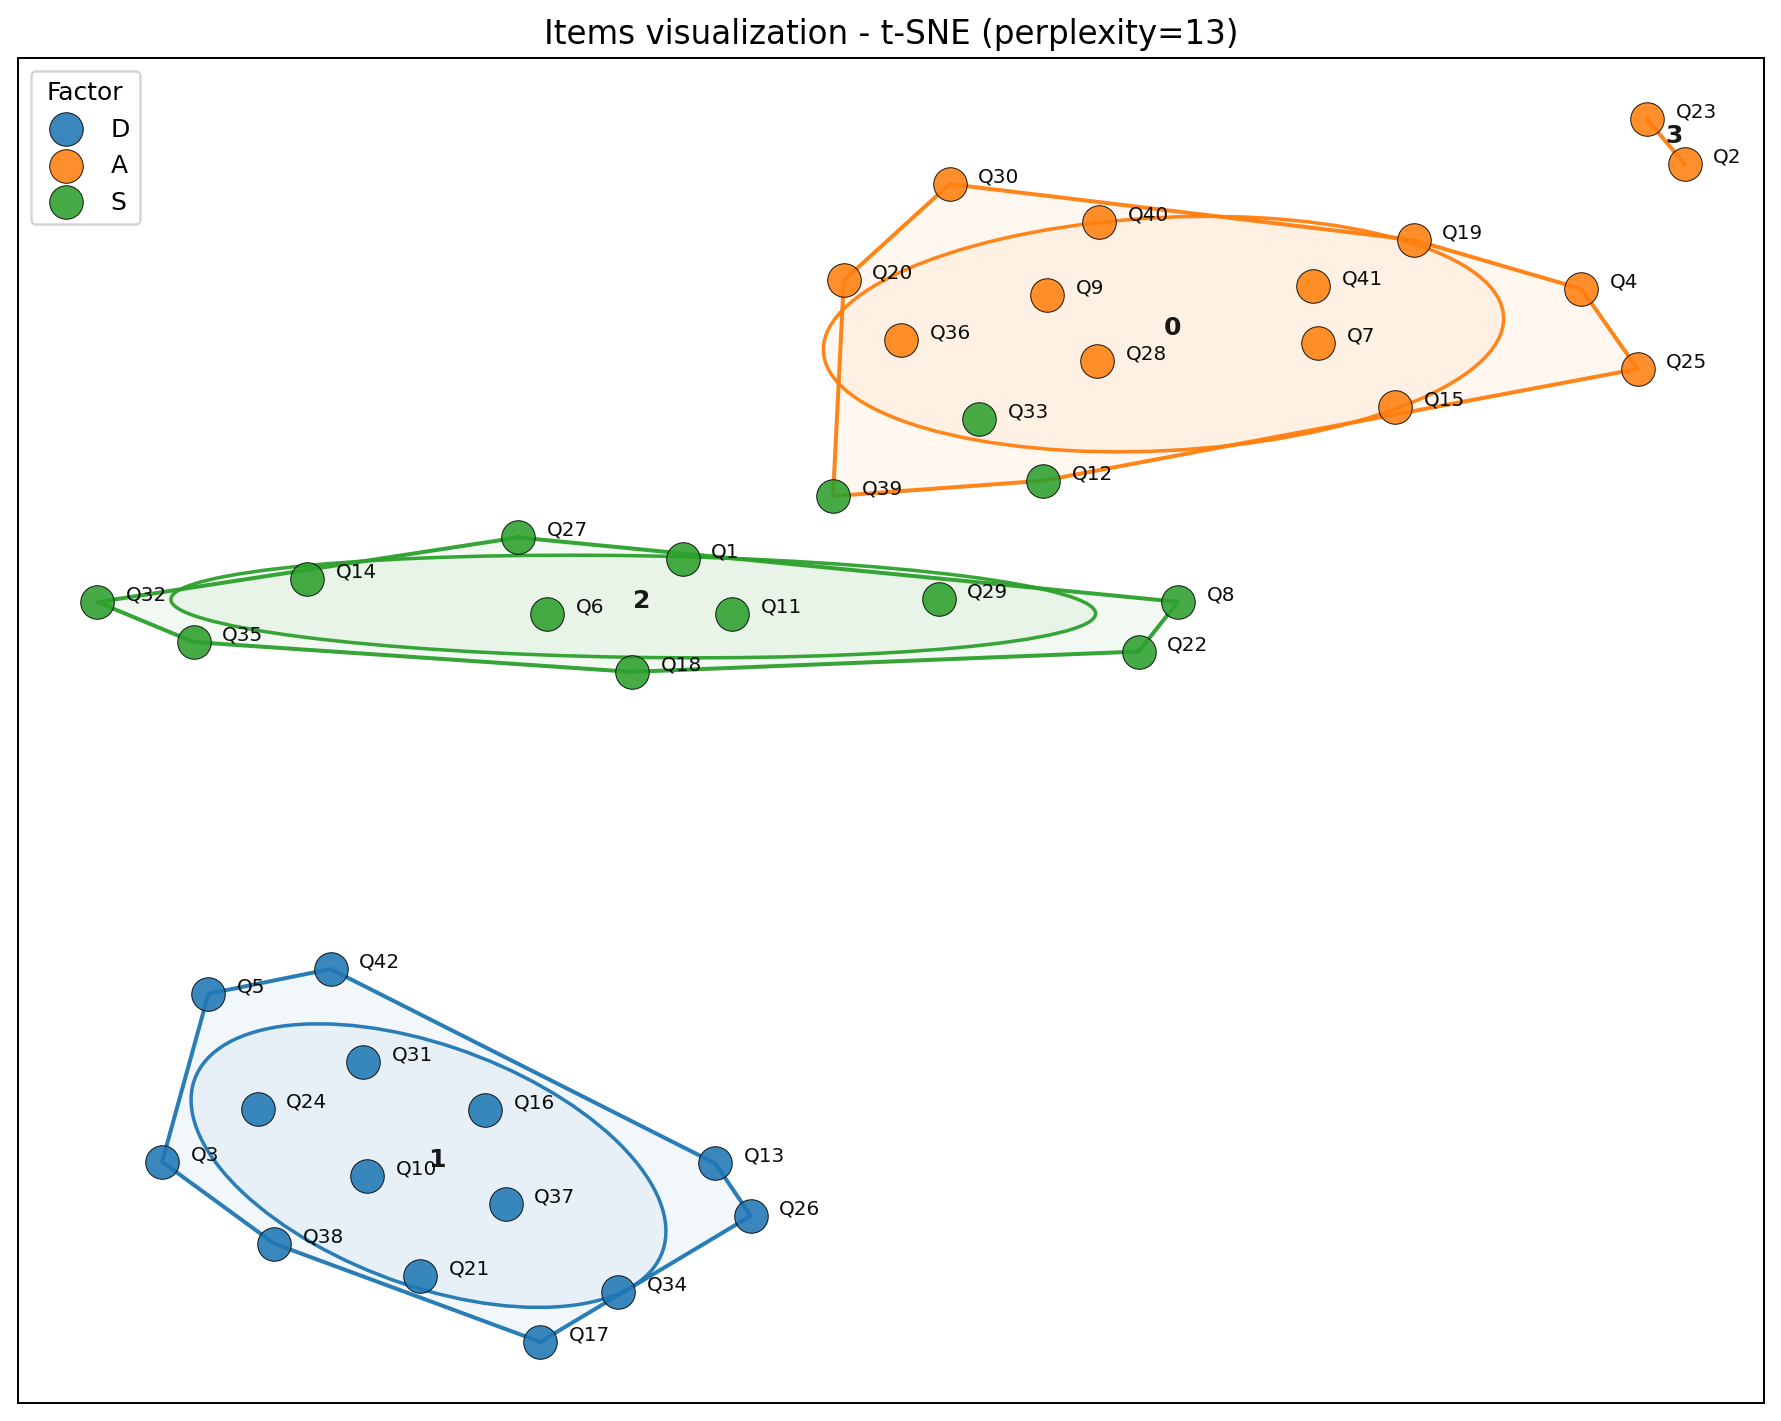

In [11]:
# 6. Plot visualization figrue
fig, ax = plt.subplots(figsize=(10, 8), dpi=180)

x_min, x_max = float(np.min(xy_tsne[:, 0])), float(np.max(xy_tsne[:, 0]))
y_min, y_max = float(np.min(xy_tsne[:, 1])), float(np.max(xy_tsne[:, 1]))
dx = (x_max - x_min) * 0.018
dy = (y_max - y_min) * 0.002

# Topic border drawing, color = majority vote
for t in topics:
    sub = df[df["Topic"].astype(str) == t]
    pts = xy_tsne[sub.index.values]
    if pts.shape[0] == 0:
        continue

    maj_fac = majority_factor(sub)
    color = factor2color.get(maj_fac, "#000000")

    draw_topic_boundary(
        ax,
        pts,
        color=color,
        draw_hull=True,
        draw_ellipse=True,
        ellipse_n_std=1.3
    )

    # topic label
    center = pts.mean(axis=0)
    ax.text(center[0], center[1], str(t), fontsize=10, fontweight="bold", alpha=0.9)

# Point drawing, color = Factor
for fac in factors:
    mask = (df["Factor"].astype(str).values == fac)
    pts = xy_tsne[mask]

    ax.scatter(
        pts[:, 0],
        pts[:, 1],
        s=180,
        alpha=0.88,
        label=fac,
        c=factor2color[fac],
        edgecolors="black",
        linewidths=0.4,
        zorder=3
    )

    # qid label
    for (x, y, q) in zip(pts[:, 0], pts[:, 1], df.loc[mask, "Qid"].values):
        ax.text(x + dx, y + dy, q, fontsize=8, alpha=0.95, zorder=5)

ax.set_title(f"Items visualization - t-SNE (perplexity={perplexity})", fontsize=13)
ax.set_xticks([])
ax.set_yticks([])
ax.legend(title="Factor", loc="best", frameon=True)

print("Two-Dimensional Visualization of the Semantic Representation Space: ")
plt.tight_layout()
plt.show()